In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

from satellite_downlink_simulator.simulation import SpectrumRecord
from carrier_generator import CarrierGenerator
from interferer_generator import InterfererGenerator
from psd_simulator import PSDSimulator
from visualization import Visualizer
from spectrum_records_utility import load_and_process_records

In [116]:
carrier_gen = CarrierGenerator(seed=42)
carrier_config = carrier_gen.generate_carriers(
    num_static_per_xpdr=(0, 10),  # Fewer carriers for quick test
    num_dynamic=5
)

simulator = PSDSimulator(
    carrier_config=carrier_config,
    interferer_configs=[],
    rbw_hz=100e3,  # 100 kHz RBW for faster generation
    vbw_hz=1e3
)

start_time = datetime(2025, 1, 15, 0, 0, 0)  # Fixed time for testing
snapshots, metadata = simulator.run_simulation(
    duration_min=60*60,  # 10 minutes
    snapshot_interval_min=1,  # 5 minute intervals = 3 snapshots
    start_datetime=start_time,
    export_json=True
)
apps_dir = "/home/harris/dev/rf-ml-v2/rf-ml/satellite_downlink_simulator/apps/rf_pattern_of_life_example/"
json_filename = f"spectrum_records_{start_time.strftime('%Y%m%d-%H%M%S')}.json"
json_filepath = apps_dir + "output/" + json_filename

Generating static carriers...
  Created 14 static carriers
Generating 5 dynamic carriers...
  Created 5 dynamic carriers
Total carriers: 19
Initialized simulator with 6 transponders
  RBW: 100.0 kHz, VBW: 1.0 kHz

Running 60.0-hour simulation...
  Snapshot interval: 1.0 min
  Total snapshots: 3601
  Processing t=0.0 hrs (1/3601 snapshots, 0%)
  Processing t=0.2 hrs (13/3601 snapshots, 0%)
  Processing t=0.4 hrs (25/3601 snapshots, 1%)
  Processing t=0.6 hrs (37/3601 snapshots, 1%)
  Processing t=0.8 hrs (49/3601 snapshots, 1%)
  Processing t=1.0 hrs (61/3601 snapshots, 2%)
  Processing t=1.2 hrs (73/3601 snapshots, 2%)
  Processing t=1.4 hrs (85/3601 snapshots, 2%)
  Processing t=1.6 hrs (97/3601 snapshots, 3%)
  Processing t=1.8 hrs (109/3601 snapshots, 3%)
  Processing t=2.0 hrs (121/3601 snapshots, 3%)
  Processing t=2.2 hrs (133/3601 snapshots, 4%)
  Processing t=2.4 hrs (145/3601 snapshots, 4%)
  Processing t=2.6 hrs (157/3601 snapshots, 4%)
  Processing t=2.8 hrs (169/3601 snapsh

In [117]:
records = SpectrumRecord.from_file(str(json_filepath))

In [118]:
data_rows = []
for record in records:
    freq_start = record.cf_hz - (record.bw_hz / 2)
    freq_end = record.cf_hz + (record.bw_hz / 2)
    frequencies = np.linspace(freq_start, freq_end, record.psd_shape[0])
    powers = record.get_psd()
    
    data_rows.append({
        'timestamp': record.timestamp,
        'cf_hz': record.cf_hz,
        'bw_hz': record.bw_hz,
        'rbw_hz': record.rbw_hz,
        'vbw_hz': record.vbw_hz,
        'frequencies': frequencies,
        'powers': powers
    })

df = pd.DataFrame(data_rows)
df = df.set_index('timestamp')

In [119]:
# Quick viz 
time_array, frequency_array, psd_array, metadata, activity_log, interferer_data = load_and_process_records(str(json_filepath))

Loading spectrum records from: /home/harris/dev/rf-ml-v2/rf-ml/satellite_downlink_simulator/apps/rf_pattern_of_life_example/output/spectrum_records_20250115-000000.json
  Loaded 3601 spectrum records
  Time range: 0.0 - 3600.0 minutes
  Frequency range: 12.200 - 12.416 GHz
  Frequency points: 2166
  Decompressing PSD data...
    Processing record 50/3601
    Processing record 100/3601
    Processing record 150/3601
    Processing record 200/3601
    Processing record 250/3601
    Processing record 300/3601
    Processing record 350/3601
    Processing record 400/3601
    Processing record 450/3601
    Processing record 500/3601
    Processing record 550/3601
    Processing record 600/3601
    Processing record 650/3601
    Processing record 700/3601
    Processing record 750/3601
    Processing record 800/3601
    Processing record 850/3601
    Processing record 900/3601
    Processing record 950/3601
    Processing record 1000/3601
    Processing record 1050/3601
    Processing record

In [120]:
viz = Visualizer(
    time_array=time_array,
    frequency_array=frequency_array,
    psd_array=psd_array,
    metadata=metadata,
    output_dir=apps_dir + "/output/"
)

Initialized visualizer
  Time range: 0.0 - 60.0 hrs
  Frequency range: 12.200 - 12.416 GHz
  PSD shape: (3601, 2166)


In [121]:
viz.create_waterfall_plot()


Creating waterfall plot...
  PSD range: -121.0 to -94.8 dBm/Hz
  Saved to /home/harris/dev/rf-ml-v2/rf-ml/satellite_downlink_simulator/apps/rf_pattern_of_life_example//output/waterfall_plot.png


In [122]:
psd_array

array([[-122.90775547, -122.93313366, -122.75788137, ..., -122.77389348,
        -122.91708945, -123.03883027],
       [-122.9701659 , -122.94451482, -122.6426528 , ..., -122.68834376,
        -122.84230099, -122.97595844],
       [-122.97933818, -122.80542395, -122.77915583, ..., -122.6079366 ,
        -122.75948642, -123.02452657],
       ...,
       [-123.10192282, -122.82649829, -122.74234132, ..., -122.75874605,
        -122.78387695, -122.98168715],
       [-123.02702918, -122.87481666, -122.77762761, ..., -122.76588484,
        -122.95455629, -123.00808983],
       [-122.99459896, -122.81296904, -122.69190253, ..., -122.6632098 ,
        -122.83571914, -123.01924148]], shape=(3601, 2166))

In [123]:
frequency_array

array([1.22000000e+10, 1.22000998e+10, 1.22001995e+10, ...,
       1.24158005e+10, 1.24159002e+10, 1.24160000e+10], shape=(2166,))

In [124]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Use PSD data directly (already in dBm/Hz, consistent scale)
# Shape: (3601 time snapshots, 2166 frequency points)

# Apply DBSCAN clustering
# eps: maximum distance between samples in a cluster (in dBm Euclidean space)
# min_samples: minimum number of samples in a neighborhood to form a cluster
dbscan = DBSCAN(eps=8.0, min_samples=5)
clusters = dbscan.fit_predict(psd_array)

# Print clustering results
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Cluster labels: {np.unique(clusters)}")
print(f"\nCluster distribution:")
for label in np.unique(clusters):
    count = np.sum(clusters == label)
    if label == -1:
        print(f"  Noise: {count} samples")
    else:
        print(f"  Cluster {label}: {count} samples")

Number of clusters: 11
Number of noise points: 0
Cluster labels: [ 0  1  2  3  4  5  6  7  8  9 10]

Cluster distribution:
  Cluster 0: 2666 samples
  Cluster 1: 281 samples
  Cluster 2: 90 samples
  Cluster 3: 50 samples
  Cluster 4: 90 samples
  Cluster 5: 61 samples
  Cluster 6: 15 samples
  Cluster 7: 20 samples
  Cluster 8: 81 samples
  Cluster 9: 66 samples
  Cluster 10: 181 samples


Saved visualization to /home/harris/dev/rf-ml-v2/rf-ml/satellite_downlink_simulator/apps/rf_pattern_of_life_example//output/dbscan_clusters.png


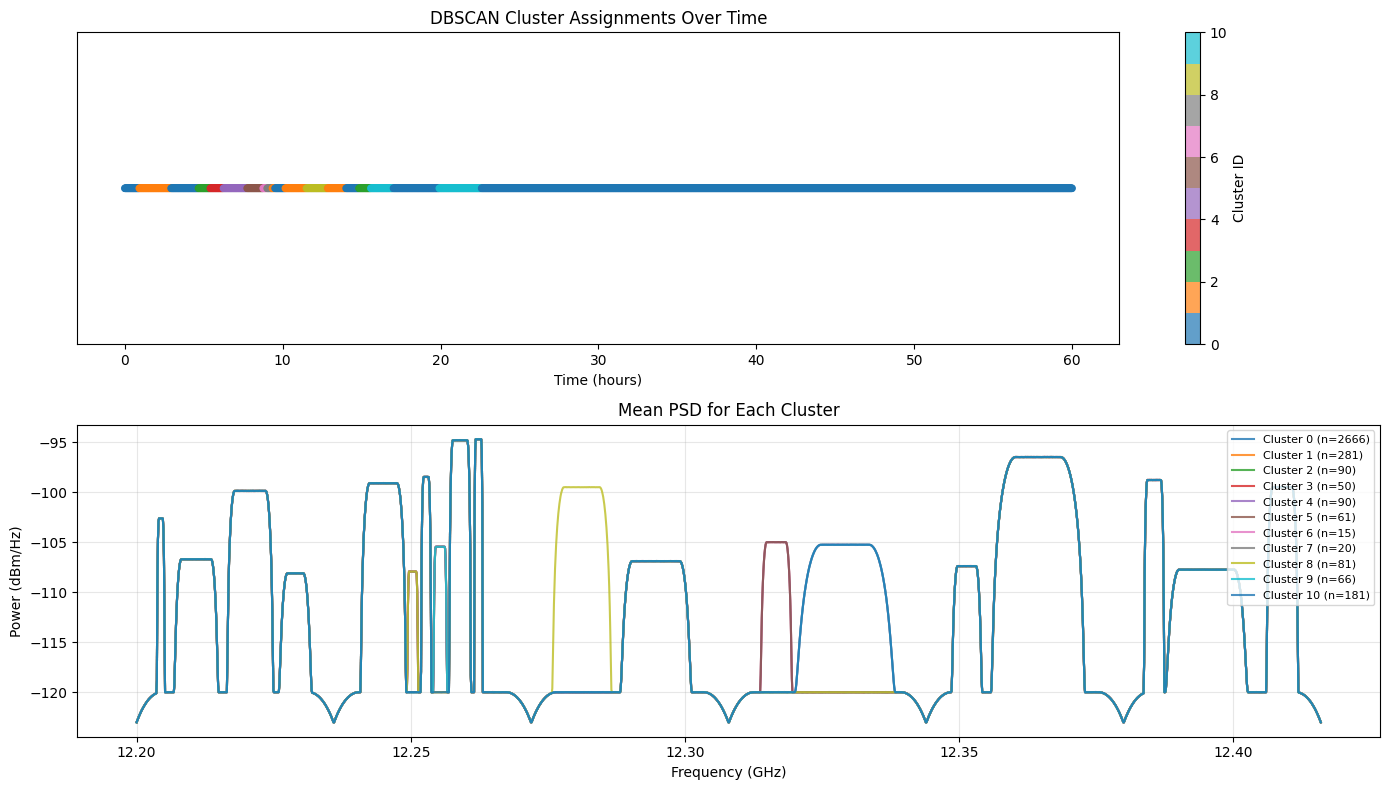

In [125]:
# Visualize clusters over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Cluster assignment over time
time_hours = time_array / 60  # Convert minutes to hours
scatter = ax1.scatter(time_hours, np.zeros_like(time_hours), c=clusters, 
                      cmap='tab10', s=20, alpha=0.7)
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('')
ax1.set_title('DBSCAN Cluster Assignments Over Time')
ax1.set_ylim(-0.5, 0.5)
ax1.set_yticks([])
plt.colorbar(scatter, ax=ax1, label='Cluster ID')

# Plot 2: Representative PSDs from each cluster
for label in np.unique(clusters):
    if label == -1:
        continue  # Skip noise points
    
    # Get all PSDs in this cluster
    cluster_mask = clusters == label
    cluster_psds = psd_array[cluster_mask]
    
    # Plot the mean PSD for this cluster
    mean_psd = np.mean(cluster_psds, axis=0)
    ax2.plot(frequency_array / 1e9, mean_psd, 
             label=f'Cluster {label} (n={np.sum(cluster_mask)})', 
             alpha=0.8, linewidth=1.5)

ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel('Power (dBm/Hz)')
ax2.set_title('Mean PSD for Each Cluster')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(apps_dir + '/output/dbscan_clusters.png', dpi=150, bbox_inches='tight')
print(f"Saved visualization to {apps_dir}/output/dbscan_clusters.png")
plt.show()